In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import odeint
import seaborn as sns

In [2]:
def plot_solutions(sol, alpham, deltam, alphap, deltap, ic_m, ic_p, scale=1):
    #Plotting
    fig, ax = plt.subplots(3,figsize=(8,6))
    #sol.plot(subplots=True,layout=(3,1),figsize=(10,6),ax=ax, xlabel="Time (min)", ylabel = "Concentration (nM)")
    ax[0].plot(sol.index,sol.mRNA, label="mRNA (nM)")
    ax[0].set_xlabel("time (min)")
    ax[0].set_ylabel("concentration (nM)")
    ax[0].legend()

    ax[1].plot(sol.index,sol.protein, label="protein (nM)")
    ax[1].set_xlabel("time (min)")
    ax[1].set_ylabel("concentration (nM)")
    ax[1].legend()


    box = ax[2].get_position()
    ax[2].set_position([box.x0, box.y0 + box.height * 0.2, box.width, box.height * 0.8])

    
    ax[2].set_xlabel("protein (nM)")
    ax[2].set_ylabel("mRNA (nM)")
    stop = 1.5*np.max(sol.protein)
    prot = np.linspace(start=0, stop=stop,num=1000)
    mrna = np.linspace(start=0, stop=1.5*np.max(sol.mRNA),num=1000)
    ax[2].plot(prot,sol.mnull, c="green", label="mnull(x)")
    ax[2].plot(prot,sol.pnull, c="blue", label="pnull(x)")
    ax[2].plot(sol.protein,sol.mRNA, c="violet", label="protein(nM)", linewidth=2)

    x,y = np.meshgrid(np.linspace(start=0, stop=stop,num=10),np.linspace(start=0, stop=1.5*np.max(sol.mRNA),num=10))
    scaling=scale
    u = (alphap*y-deltap*x)*scaling
    v = (np.mean(sol.mRNA[-50:])-deltam*y)*scaling

    # vector: (alphap*y-deltap*x):(alpham-deltam*y)

    ax[2].quiver(x,y,u,v,color='grey',  angles='xy', scale_units='xy', scale=2, width=0.002, label="Vector field")


    ax[2].legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), fancybox=True, shadow=True, ncol=5)
    plt.suptitle(rf"[$\alpha_m$={alpham}/$\delta_m$={deltam}] $m_0$=({ic_m})    [$\alpha_p$={alphap}/$\delta_p$={deltap}] $p_0$=({ic_p})  ")
    fig.subplots_adjust(top=0.8)
    fig.align_ylabels()
    plt.tight_layout()
    plt.show()



#sol
#plot_solutions(sol, alpham, deltam, alphap, deltap, ic_m, ic_p)


In [3]:
def gillespie(alpham, deltam, alphap, deltap,
              M0, P0,
              tmax,
              self_reg=False,
              n=2, K=1000):

    NA = 6.022e23
    V = 10e-15
    conv = 1e-9 * NA * V   # nM -> molecules
    
    alpham = alpham * conv   # convert to molecule production rate
    
    t = 0
    M = int(M0)
    P = int(P0)

    times = [t]
    mRNA = [M]
    protein = [P]

    while t < tmax: # not using discrete time steps

        # --- propensities ---
        if self_reg:
            a1 = alpham * (K**n / (P**n + K**n + 1e-12))
        else:
            a1 = alpham

        a2 = deltam * M
        a3 = alphap * M
        a4 = deltap * P

        a0 = a1 + a2 + a3 + a4
        if a0 == 0:
            break

        # --- time to next reaction ---
        r1 = np.random.rand()
        tau = -np.log(r1) / a0
        t += tau

        # --- determine which reaction fires ---
        r2 = np.random.rand() * a0

        # M -> M+1
        if r2 < a1:
            M += 1

        # M -> M-1
        elif r2 < a1 + a2:
            if M > 0:
                M -= 1

        # P -> P+1
        elif r2 < a1 + a2 + a3:
            P += 1

        # P -> P-1
        else:
            if P > 0:
                P -= 1

        times.append(t)
        mRNA.append(M)
        protein.append(P)

    return np.array(times), np.array(mRNA), np.array(protein)

In [ ]:
# DETERMINISTIC DYNAMICS

nequ=2
alpham=10100.0
deltam=1.0
alphap=10.0
deltap=0.1
k=1000
ic_m=0.0
ic_p=0.0

#initial conditions
y0 =  [] 
y0.append(ic_m)
y0.append(ic_p)
#y0.append(alphap*alpham/(deltap*deltam))


#Derivatives
def dy_dt(y,t):    
    dy = []
    f_p = (k*k)/(k*k + y[1]*y[1])
    dy.append(alpham*f_p-deltam*y[0])
    #dy.append(alpham-deltam*y[0])
    dy.append(alphap*y[0]-deltap*y[1])
   
    return dy    

#Integration of ODEs
tmax=100
t = np.linspace(start=0, stop=tmax,num=1000)
prot = np.linspace(start=0, stop=15000,num=1000)
sol = odeint(func=dy_dt, y0=y0, t=t)
sol = pd.DataFrame(sol, columns=["mRNA","protein"])
sol *= 6.022
sol.index = t
#sol.index = sol.index/60

sol["mnull"] = (100/deltam)*6.022
sol["pnull"] = (deltap*prot/alphap)*6.022
#plot_solutions(sol, alpham, deltam, alphap, deltap, ic_m, ic_p)

In [52]:
# Declaring here so can do multiple runs up to n=1000
M_f=[]
P_f=[]

In [56]:
# RUNS FOR DISTRIBUTIONS
num_runs=500
tmax = 20
self_reg = True
K=602

#M_f = []
alpham=10100
deltam=1
M0 = 602 # Deterministic steady state value

#P_f = []
alphap=10
deltap=0.1
P0 = 60000 # deterministic steady state value


for i in range(num_runs):
    t, M, P = gillespie(alpham=alpham,
                    deltam=deltam,
                    alphap=alphap,
                    deltap=deltap,
                    M0=M0,
                    P0=P0,
                    tmax=tmax,
                    self_reg=self_reg,
                    n=2,
                    K=K)
    M_f.append(np.mean(M[-1]))
    P_f.append(P[-1])
    if (i+1)%25==0:
        print(i+1,end=' ')


25 50 75 100 125 150 175 200 225 250 275 300 325 350 375 400 425 450 475 500 

In [ ]:
# GET 2 STOCHASTIC SIMULATIONS FOR PLOTTING AND COMPARING AGAINST THE DETERMINISTIC
M0=0
P0=0
alpham = 10100
alphap = 10
tmax=100
self_reg=True

t, M, P = gillespie(alpham=alpham,
                    deltam=deltam,
                    alphap=alphap,
                    deltap=deltap,
                    M0=M0,
                    P0=P0,
                    tmax=tmax,
                    self_reg=self_reg,
                    n=2,
                    K=K)
stoch_sol=np.asarray([M,P])
stoch_sol = pd.DataFrame(stoch_sol.T, columns=["mRNA","protein"])
#stoch_sol["mnull"] = alpham/deltam 
alpham_ = 100
stoch_sol['mnull'] = np.full_like(alpham_, fill_value=6.022*alpham_)
stop = 1.5*np.max(stoch_sol.protein)
prot = np.linspace(start=0, stop=stop,num=len(stoch_sol['protein']))
stoch_sol["pnull"] = deltap*prot/alphap

N = 1000
window = len(stoch_sol) // N

stoch_small = (
    stoch_sol
    .iloc[:N*window]                    # trim to exact multiple
    .groupby(np.arange(N*window)//window)
    .mean()
)
t, M, P = gillespie(alpham=alpham,
                    deltam=deltam,
                    alphap=alphap,
                    deltap=deltap,
                    M0=M0,
                    P0=P0,
                    tmax=tmax,
                    self_reg=self_reg,
                    n=2,
                    K=K)
stoch_sol2=np.asarray([M,P])
stoch_sol2 = pd.DataFrame(stoch_sol2.T, columns=["mRNA","protein"])
#stoch_sol["mnull"] = alpham/deltam 
stoch_sol2['mnull'] = np.full_like(alpham_, fill_value=6.022*alpham_)
stop = 1.5*np.max(stoch_sol2.protein)
prot = np.linspace(start=0, stop=stop,num=len(stoch_sol2['protein']))
stoch_sol2["pnull"] = deltap*prot/alphap

N = 1000
window = len(stoch_sol2) // N

stoch_small2 = (
    stoch_sol2
    .iloc[:N*window]                    # trim to exact multiple
    .groupby(np.arange(N*window)//window)
    .mean()
)

In [50]:
def plot_three_solutions(sol,sol2, sol3, alpham, deltam, alphap, deltap, ic_m, ic_p, scale=1):
    #Plotting
    fig, ax = plt.subplots(4,figsize=(8,10))
    
    #----------------------------------------------------------------------#
    ax[0].plot(sol.index,sol.mRNA,  marker='o', fillstyle='none', markevery=50, linestyle='-',  linewidth=1, color='black', label="[D] mRNA (nM)",)
    ax[0].plot(sol.index,sol2.mRNA, marker='^', fillstyle='none', markevery=50, linestyle='--', linewidth=1, color='black', label="[ST] mRNA (nM)")
    ax[0].plot(sol.index,sol3.mRNA, marker='^', fillstyle='full', markevery=50, linestyle='--', linewidth=1, color='black', label="[ST] mRNA (nM)")
    ax[0].set_xlabel("time (min)")
    ax[0].set_ylabel("mRNA concentration ")
    ax[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), fancybox=True, shadow=True, ncol=3)

    #----------------------------------------------------------------------#

    ax[1].plot(sol.index,sol.protein,  marker='o', fillstyle='none', markevery=50, linestyle='-',   linewidth=1, color='black', label="[D] protein (nM)")
    ax[1].plot(sol.index,sol2.protein, marker='^', fillstyle='none', markevery=50, linestyle='--',  linewidth=1, color='black', label="[ST] protein (nM)")
    ax[1].plot(sol.index,sol3.protein, marker='^', fillstyle='full', markevery=50, linestyle='--',  linewidth=1, color='black', label="[ST] protein (nM)")
    ax[1].set_xlabel("time (min)")
    ax[1].set_ylabel("protein concentration")
    ax[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), fancybox=True, shadow=True, ncol=3)


    #box = ax[2].get_position()
    #ax[2].set_position([box.x0, box.y0 + box.height * 0.2, box.width, box.height * 0.8])
    #----------------------------------------------------------------------#
    ax[2].set_xlabel("protein concentration")
    ax[2].set_ylabel("mRNA concentration")
    stop = 1.5*np.max(sol.protein)
    prot = np.linspace(start=0, stop=stop,num=1000)
    mrna = np.linspace(start=0, stop=1.5*np.max(sol.mRNA),num=1000)
    ax[2].plot(prot,sol.mnull, c="orange", label="mRNA nullcline")
    ax[2].plot(prot,sol.pnull, c="blue", label="protein nullcline")
    ax[2].plot(sol.protein,sol.mRNA,marker='o', fillstyle='none', markevery=50, linestyle='-',  linewidth=1, color='black', label="[D] (protein, mRNA)(nM)")

    x,y = np.meshgrid(np.linspace(start=0, stop=stop,num=10),np.linspace(start=0, stop=1.5*np.max(sol.mRNA),num=10))
    scaling=scale
    u = (alphap*y-deltap*x)*scaling
    v = (np.mean(sol.mRNA[-50:])-deltam*y)*scaling

    ax[2].quiver(x,y,u,v,color='grey',  angles='xy', scale_units='xy', scale=10, width=0.002, label="Vector field")
    ax[2].legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), fancybox=True, shadow=True, ncol=4)
    
    #----------------------------------------------------------------------#
    
    ax[3].set_xlabel("protein concentration")
    ax[3].set_ylabel("mRNA concentration")
    stop = 1.5*np.max(sol2.protein)
    prot = np.linspace(start=0, stop=stop,num=1000)
    mrna = np.linspace(start=0, stop=1.5*np.max(sol2.mRNA),num=1000)
    ax[3].plot(prot,sol2.mnull, c="orange", label="mRNA nullcline")
    ax[3].plot(prot,sol2.pnull, c="blue", label="protein nullcline")
    ax[3].plot(sol2.protein,sol2.mRNA, marker='^', fillstyle='none', markevery=50, linestyle='--',  linewidth=1, color='black', label="[ST1] (protein, mRNA)")
    ax[3].plot(sol3.protein,sol3.mRNA, marker='^', fillstyle='full', markevery=50, linestyle=':',   linewidth=1, color='black', label="[ST2] (protein, mRNA)")

    x,y = np.meshgrid(np.linspace(start=0, stop=stop,num=10),np.linspace(start=0, stop=1.5*np.max(sol2.mRNA),num=10))
    scaling=scale
    u = (alphap*y-deltap*x)*scaling
    v = (np.mean(sol2.mRNA[-50:])-deltam*y)*scaling

    ax[3].quiver(x,y,u,v,color='grey',  angles='xy', scale_units='xy', scale=10, width=0.002, label="Vector field")
    ax[3].legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), fancybox=True, shadow=True, ncol=3)

    #----------------------------------------------------------------------#
    


    plt.suptitle(rf"Simulation Parameters: " "\n" rf"$\alpha_m$={alpham} $\delta_m$={deltam} $M_0$=0     $\alpha_p$={alphap} $\delta_p$={deltap} $P_0$=0     self_reg={self_reg}")
    fig.subplots_adjust(top=0.8)
    fig.align_ylabels()
    plt.tight_layout()
    plt.show()



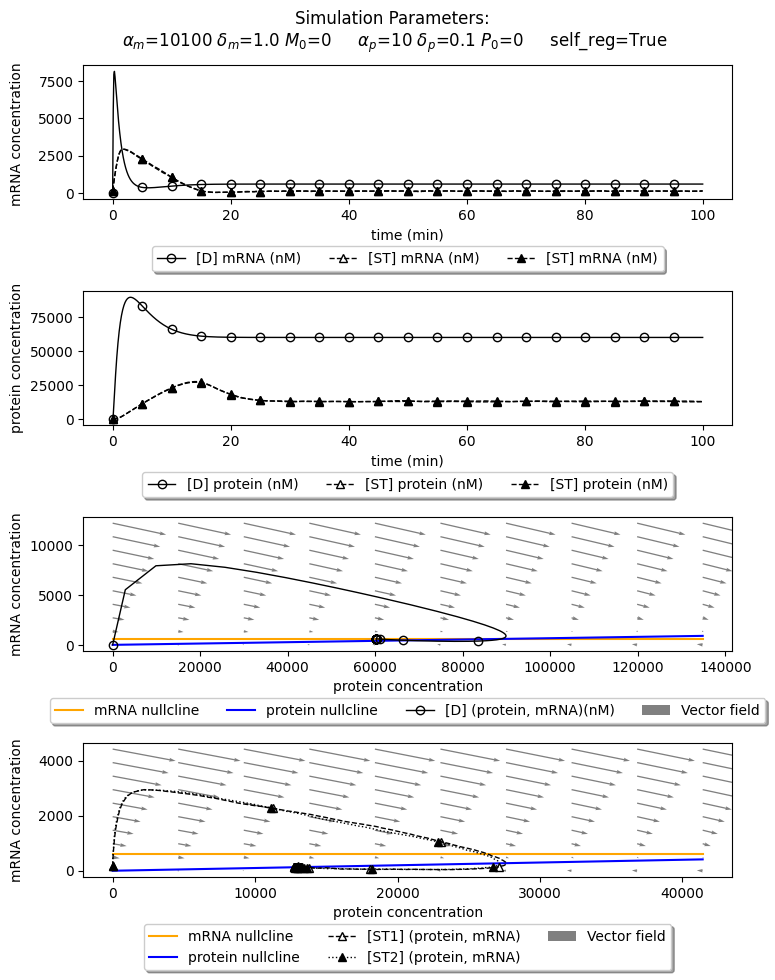

In [ ]:
# PLOT DETERMINISTIC v 2xSTOCHASTIC
plot_three_solutions(sol, stoch_small, stoch_small2, alpham, deltam, alphap, deltap, ic_m, ic_p)

/Users/peterclark/opt/anaconda3/envs/main/lib/python3.10/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


Text(125, 0.027, '$\\mu$=106.97')

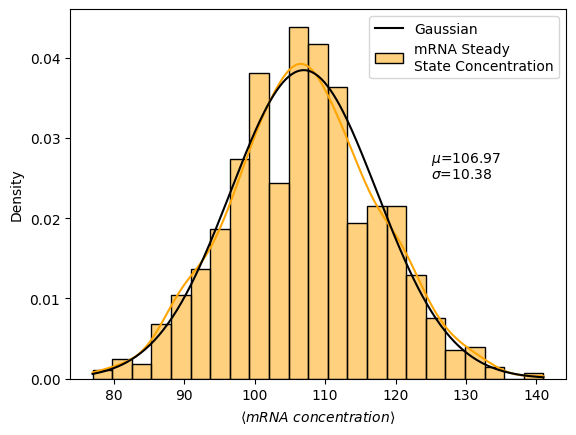

In [64]:
# mRNA steady state normalized histogram

sns.histplot(M_f, stat='density', kde=True, color='orange', label='mRNA Steady \nState Concentration')
sns.lineplot(np.linspace(min(M_f), max(M_f), 300),
         1/(np.std(M_f)*np.sqrt(2*np.pi)) *
         np.exp(-(np.linspace(min(M_f), max(M_f), 300)-np.mean(M_f))**2 /
                (2*np.std(M_f)**2)), color='black', label='Gaussian')
plt.xlabel(r"${\langle} mRNA\ concentration {\rangle}$")
plt.text(s=rf"$\sigma$={np.std(M_f):.2f}", x=125, y=0.025)
plt.text(s=rf"$\mu$={np.mean(M_f):.2f}", x=125, y=0.027)


/Users/peterclark/opt/anaconda3/envs/main/lib/python3.10/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


Text(14300, 0.0012, '$\\mu$=13964.61')

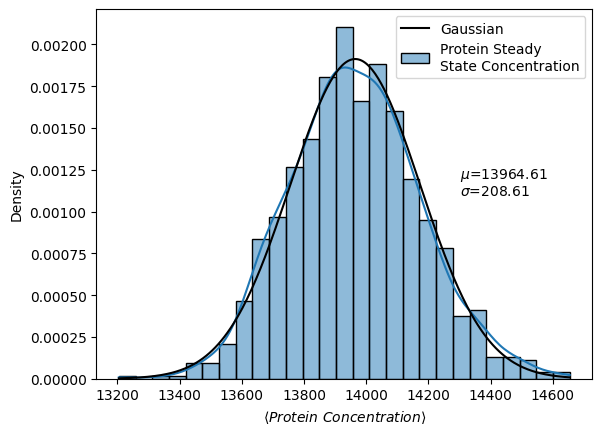

In [63]:
# protein steady state normalized histogram

sns.histplot(P_f, stat='density', kde=True, label='Protein Steady \nState Concentration')
sns.lineplot(np.linspace(min(P_f), max(P_f), 300),
         1/(np.std(P_f)*np.sqrt(2*np.pi)) *
         np.exp(-(np.linspace(min(P_f), max(P_f), 300)-np.mean(P_f))**2 /
                (2*np.std(P_f)**2)), color='black', label='Gaussian')
plt.xlabel(r"${\langle} Protein\ Concentration {\rangle}$")
plt.text(s=rf"$\sigma$={np.std(P_f):.2f}", x=14300, y=0.0011)
plt.text(s=rf"$\mu$={np.mean(P_f):.2f}", x=14300, y=0.0012)

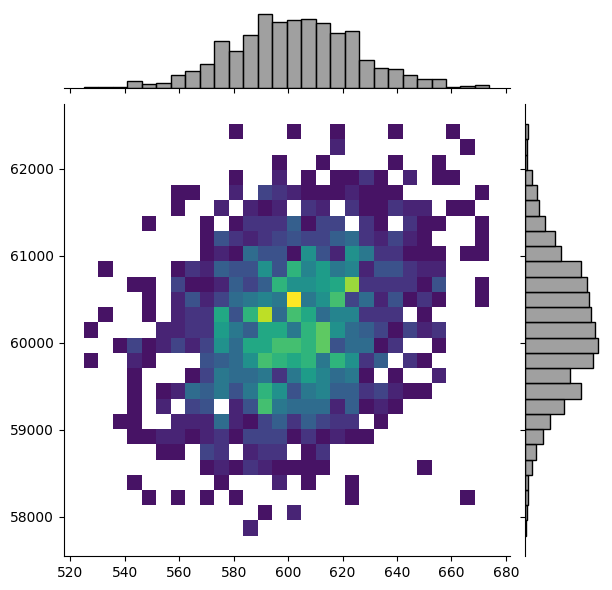

In [304]:
P_f=np.asarray(P_f, dtype=float)
M_f=np.asarray(M_f, dtype=float)
sns.jointplot(x=M_f, y=P_f, kind='hist', cmap='viridis', color='gray')